# 03 — Modelling: BERTopic Hyperparameter Experimentation
### Topic Modelling on India News Headlines (2001–2023)

**Goal of this notebook:** run a series of BERTopic configurations — varying the embedding
model, UMAP dimensionality-reduction settings, and HDBSCAN clustering settings — score each one,
and identify the best-performing configuration with a documented justification.

**How BERTopic works, in short:**
1. **Embed** every headline into a dense vector using a sentence-Transformer.
2. **Reduce dimensionality** with **UMAP** (Transformer embeddings are 384-768 dimensions;
   clustering works better, and faster, in a smaller space).
3. **Cluster** the reduced embeddings with **HDBSCAN** (density-based — finds clusters of
   varying shapes/sizes and explicitly marks low-density points as outliers, rather than forcing
   every document into a cluster).
4. **Represent each cluster as a topic** using **c-TF-IDF** — finds the words most distinctive
   to each cluster, giving each topic a ranked keyword list.

**Why we experiment with hyperparameters:**
- **`n_neighbors` (UMAP)** — how many nearby points UMAP considers per document. Low = more,
  smaller topics; high = fewer, broader topics.
- **`n_components` (UMAP)** — how many dimensions to reduce down to.
- **`min_cluster_size` (HDBSCAN)** — minimum documents to count as a valid topic. Low = many
  small/granular topics; high = fewer, broader topics.
- **`min_samples` (HDBSCAN)** — how conservative clustering is about calling a point an outlier.

## Important: search phase uses a subsample, memory-managed per run

Running the full grid on all 285k documents, keeping every fitted model in memory, exhausted
Colab's RAM in an earlier version of this notebook. Two fixes are built in here:

1. **Grid search runs on a fixed subsample** (`SEARCH_SAMPLE_SIZE`, default 75,000 documents,
   stratified nowhere special — a plain random sample is fine for *comparing* hyperparameters,
   since we only need relative differences between configurations, not the final production
   topics). This cuts both runtime and memory substantially. Once we know the best
   configuration, we refit **only that one** on the full 285k-document dataset at the end.
2. **Results are saved to a CSV after every single run**, and the model itself is saved to disk
   and then explicitly removed from memory (`del` + `gc.collect()`) before the next run starts.
   This means: (a) memory never holds more than one fitted model at a time, and (b) if the
   session crashes at run 7, runs 0-6 are already safely saved — just re-run the loop cell and
   it will skip runs already in the results file and continue from where it stopped.

**Run this in Google Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU).


In [27]:
import os
# No Google Drive needed anymore — all storage is local to this Colab session.
# IMPORTANT: this means notebooks 01-04 must be run in ONE continuous session
# (local /content/ storage does not persist across separate sessions the way Drive did).
BASE_DIR = '/content/topic-modelling-capstone'
DATA_PROCESSED = f'{BASE_DIR}/data/processed'
OUTPUTS_MODELS = f'{BASE_DIR}/outputs/models'
OUTPUTS_FIGURES = f'{BASE_DIR}/outputs/figures'
EMBEDDINGS_CACHE = f'{BASE_DIR}/outputs/embeddings'
for d in [OUTPUTS_MODELS, OUTPUTS_FIGURES, EMBEDDINGS_CACHE]:
    os.makedirs(d, exist_ok=True)


In [28]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim

import pandas as pd
import numpy as np
import time
import gc
import pickle

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import torch
print("GPU available:", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.5 MB/s eta 0:00:00
GPU available: True


## 1. Load preprocessed data from notebook 02

In [29]:
df = pd.read_csv(f'{DATA_PROCESSED}/headlines_preprocessed.csv')
print(f"Loaded {len(df):,} rows")

docs_embed = df['text_for_embedding'].astype(str).tolist()
docs_repr = df['text_for_representation'].astype(str).tolist()

print(f"Documents ready for modelling: {len(docs_embed):,}")


Loaded 284,916 rows
Documents ready for modelling: 284,916


## 2. Embedding models to compare, and a caching helper

Embeddings for the **full** dataset are computed once per model and cached to Drive — needed
both for the search-phase subsample (drawn from these) and for the final full-data refit.


In [30]:
EMBEDDING_MODELS = {
    'MiniLM-L6-v2': 'sentence-transformers/all-MiniLM-L6-v2',
    'mpnet-base-v2': 'sentence-transformers/all-mpnet-base-v2',
}

def get_embeddings(model_key, model_name, docs, chunk_size=20_000):
    """Same as before, but encodes in chunks and saves progress after each one — a crash or
    interruption partway through only costs the current chunk, not the whole computation. On
    resume, already-completed chunks are detected and skipped."""
    cache_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings.npy'
    progress_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings_partial.npy'
    progress_meta_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings_progress.txt'

    if os.path.exists(cache_path):
        print(f"Loading cached embeddings for {model_key} from disk...")
        return np.load(cache_path)

    print(f"Computing embeddings for {model_key} ({model_name}) in chunks of {chunk_size:,}...")
    model = SentenceTransformer(model_name)

    start_idx = 0
    chunks = []
    if os.path.exists(progress_path) and os.path.exists(progress_meta_path):
        with open(progress_meta_path) as f:
            start_idx = int(f.read().strip())
        chunks = [np.load(progress_path)]
        print(f"Resuming from document {start_idx:,} (found existing partial progress).")

    total = len(docs)
    while start_idx < total:
        end_idx = min(start_idx + chunk_size, total)
        batch_embeddings = model.encode(docs[start_idx:end_idx], show_progress_bar=True, batch_size=256)
        chunks.append(batch_embeddings)

        # Save progress after every chunk — this is what makes it resumable.
        partial = np.concatenate(chunks)
        np.save(progress_path, partial)
        with open(progress_meta_path, 'w') as f:
            f.write(str(end_idx))
        print(f"  Checkpointed {end_idx:,}/{total:,} documents ({end_idx/total:.1%})")

        start_idx = end_idx

    embeddings = np.concatenate(chunks)
    np.save(cache_path, embeddings)
    # Clean up the partial-progress files now that the full array is safely saved.
    for p in [progress_path, progress_meta_path]:
        if os.path.exists(p):
            os.remove(p)

    print(f"Done. Shape: {embeddings.shape}. Cached to {cache_path}")
    return embeddings


def _unused_original_get_embeddings(model_key, model_name, docs):
    cache_path = f'{EMBEDDINGS_CACHE}/{model_key}_embeddings.npy'
    if os.path.exists(cache_path):
        print(f"Loading cached embeddings for {model_key} (already computed this session)...")
        return np.load(cache_path)

    print(f"Computing embeddings for {model_key} ({model_name})... this is the slow step.")
    model = SentenceTransformer(model_name)
    start = time.time()
    embeddings = model.encode(docs, show_progress_bar=True, batch_size=256)
    elapsed = time.time() - start
    print(f"Done in {elapsed/60:.1f} minutes. Shape: {embeddings.shape}")

    np.save(cache_path, embeddings)
    print(f"Cached to {cache_path}")
    return embeddings


## 3. Compute (or load cached) FULL-dataset embeddings

Only computing `MiniLM-L6-v2` for now, since the starting grid uses one embedding model — add
`mpnet-base-v2` here too once you're ready to expand the grid to compare embedding models.


In [31]:
# Trimmed to only what's actually needed: if you already have all grid-search results
# (e.g. restored from a Drive backup after a session was interrupted), MiniLM-L6-v2's
# embeddings are never touched again — only the winning configuration's embedding model
# (mpnet-base-v2, per run_20) is needed for the final full-dataset refit. Add
# 'MiniLM-L6-v2' back here only if you need to redo/extend the grid search itself.
ACTIVE_EMBEDDING_MODELS = ['mpnet-base-v2']

embeddings_by_model = {}
for key in ACTIVE_EMBEDDING_MODELS:
    embeddings_by_model[key] = get_embeddings(key, EMBEDDING_MODELS[key], docs_embed)

for key, emb in embeddings_by_model.items():
    print(f"{key}: shape {emb.shape}")


Loading cached embeddings for mpnet-base-v2 from disk...
mpnet-base-v2: shape (284916, 768)


## 4. Build the search-phase subsample

A fixed random subsample used for *all* grid-search runs below — keeps every run's memory/time
footprint small and comparable. The winning configuration gets refit on the full dataset later.


In [32]:
SEARCH_SAMPLE_SIZE = 75_000

rng = np.random.RandomState(RANDOM_STATE)
search_idx = rng.choice(len(docs_repr), size=min(SEARCH_SAMPLE_SIZE, len(docs_repr)), replace=False)
search_idx.sort()  # keep original order — not required, just tidy

docs_repr_search = [docs_repr[i] for i in search_idx]
docs_tokenized_search = [d.split() for d in docs_repr_search]

embeddings_search_by_model = {
    key: emb[search_idx] for key, emb in embeddings_by_model.items()
}

print(f"Search subsample: {len(docs_repr_search):,} documents")


Search subsample: 75,000 documents


## 5. Coherence & diversity evaluation helpers

**Coherence (c_npmi)** measures how semantically related each topic's top words are, based on
corpus co-occurrence — higher is better. **Diversity** measures what fraction of top words
across all topics are unique — low diversity means topics repeat similar keywords.


In [33]:
def compute_coherence(topic_model, docs_tokenized, top_n=10):
    dictionary = Dictionary(docs_tokenized)

    topics = topic_model.get_topics()
    topic_words = [
        [word for word, _ in words[:top_n]]
        for topic_id, words in topics.items()
        if topic_id != -1
    ]
    topic_words = [t for t in topic_words if all(dictionary.token2id.get(w) is not None for w in t)]

    if len(topic_words) < 2:
        return np.nan

    cm = CoherenceModel(topics=topic_words, texts=docs_tokenized, dictionary=dictionary,
                         coherence='c_npmi')
    score = cm.get_coherence()
    del cm, dictionary
    return score


def compute_diversity(topic_model, top_n=10):
    topics = topic_model.get_topics()
    all_words = []
    for topic_id, words in topics.items():
        if topic_id == -1:
            continue
        all_words.extend([w for w, _ in words[:top_n]])
    if len(all_words) == 0:
        return np.nan
    return len(set(all_words)) / len(all_words)


### A note on `min_topic_size` vs. `min_cluster_size`

BERTopic's top-level constructor exposes a parameter called `min_topic_size`, which internally
sets HDBSCAN's `min_cluster_size` — but only when BERTopic is left to build its own default
HDBSCAN instance. In this notebook, a custom, fully-configured `HDBSCAN` object is passed in
directly (`hdbscan_model=hdbscan_model`), which is what additionally allowed tuning
`min_samples` and `cluster_selection_epsilon`, beyond what `min_topic_size` alone would expose.
Every experiment that varied `min_cluster_size` in the grid above is therefore tuning the exact
same underlying value `min_topic_size` controls in BERTopic's simpler default configuration —
just through the more flexible entry point.


## 6. The experiment grid

`min_cluster_size` values are pushed noticeably higher than a first pass would suggest — on
~75k-285k short-text documents, small `min_cluster_size` values (20-50) produce hundreds to
over a thousand topics, which is both uninterpretable and makes coherence unreliable (too few
documents per topic in the evaluation sample). Starting grid: **10 configurations**.


In [34]:
EXPERIMENT_GRID = [
    # --- varying UMAP n_neighbors, moderate min_cluster_size ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 10, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # --- varying HDBSCAN min_cluster_size (topic count / size) ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 75,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 300, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 500, 'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # --- varying UMAP n_components ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 10, 'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 15, 'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # --- varying HDBSCAN min_samples (outlier strictness) ---
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': 10, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5,  'min_cluster_size': 150, 'min_samples': 50, 'cluster_selection_epsilon': 0.0},

    # ================= ROUND 2 =================
    # min_cluster_size was the strongest driver of coherence in round 1 (monotonic: higher = better).
    # Pushing further in that direction, and combining with the n_neighbors trend that also helped.
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 700,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 1000, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 700,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 20, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 800,  'min_samples': None, 'cluster_selection_epsilon': 0.0},

    # cluster_selection_epsilon: lets HDBSCAN merge nearby low-density micro-clusters into their
    # neighbor instead of discarding them as outliers — directly targets the persistently high
    # (44-56%) outlier rate seen in every round-1 run.
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.3},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.5},
    {'embedding_model': 'MiniLM-L6-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 500,  'min_samples': None, 'cluster_selection_epsilon': 0.3},

    # mpnet-base-v2: larger, generally higher-quality embeddings — worth checking whether it
    # changes the picture now that we have a sensible MiniLM baseline to compare against.
    {'embedding_model': 'mpnet-base-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 500, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'mpnet-base-v2', 'n_neighbors': 30, 'n_components': 5, 'min_cluster_size': 500, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
    {'embedding_model': 'mpnet-base-v2', 'n_neighbors': 15, 'n_components': 5, 'min_cluster_size': 150, 'min_samples': None, 'cluster_selection_epsilon': 0.0},
]

print(f"{len(EXPERIMENT_GRID)} configurations queued.")


22 configurations queued.


## 7. Run the grid — crash-resistant version

Each run: fit on the search subsample, score it, **append the result to a CSV immediately**,
save the fitted model to disk, then free it from memory before starting the next run. If this
cell is interrupted (crash, disconnect, manual stop), just **re-run this cell** — it checks the
results CSV and skips any `run_id` already completed.


In [35]:
# --- Lightweight Drive checkpoint (optional, cheap) ---
# The full-data embeddings/model are too large for Drive right now, but the results CSV itself
# is tiny (a few KB even with 20+ rows). Checkpointing just this file to Drive means that even
# if this session's local storage gets wiped (e.g. Colab recycles the VM during a long-running
# grid search), you won't lose already-completed run results — only the recompute time for
# embeddings. Wrapped in try/except throughout: if Drive is unavailable or truly has zero space
# left, this quietly falls back to local-only storage rather than crashing anything.
CHECKPOINT_TO_DRIVE = True  # set False to skip entirely and stay fully local

if CHECKPOINT_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_BACKUP_DIR = '/content/drive/MyDrive/topic-modelling-capstone/outputs/models'
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        DRIVE_BACKUP_CSV = f'{DRIVE_BACKUP_DIR}/experiment_results_backup.csv'
    except Exception as e:
        print(f"Drive checkpoint unavailable ({e}) — continuing with local-only storage.")
        CHECKPOINT_TO_DRIVE = False
else:
    print("Drive checkpointing disabled — results will only exist locally this session.")

RESULTS_CSV = f'{OUTPUTS_MODELS}/experiment_results.csv'

# Fixed column schema — every row written to RESULTS_CSV is reindexed to exactly this,
# regardless of which keys happen to be in a given run's config dict.
CSV_COLUMNS = ['run_id', 'embedding_model', 'n_neighbors', 'n_components', 'min_cluster_size',
               'min_samples', 'cluster_selection_epsilon', 'n_topics', 'pct_outliers',
               'coherence_npmi', 'diversity', 'runtime_sec']
vectorizer_model = CountVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2))
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

def load_or_heal_results(path, expected_columns):
    """Read the results CSV, auto-repairing it if any row has a different column count
    than `expected_columns` (e.g. from an older version of this notebook that wrote a
    different set of columns before a grid parameter was added). Legacy rows missing a
    later-added column (like cluster_selection_epsilon) get that column filled with a
    default of 0.0. This makes the notebook self-healing — no manual repair step needed,
    ever, regardless of what state the file is in when this cell runs."""
    if not os.path.exists(path):
        return pd.DataFrame(columns=expected_columns)

    import csv
    with open(path, newline='') as f:
        raw_rows = list(csv.reader(f))

    if len(raw_rows) == 0:
        return pd.DataFrame(columns=expected_columns)

    existing_header = raw_rows[0]
    needs_repair = (existing_header != expected_columns) or any(
        len(r) != len(expected_columns) for r in raw_rows[1:]
    )

    if not needs_repair:
        return pd.read_csv(path)

    print("Detected an inconsistent results CSV schema — auto-repairing...")
    fixed_rows = [expected_columns]
    for r in raw_rows[1:]:
        if r == expected_columns:
            continue  # a stray duplicate header row, drop it
        if len(r) == len(expected_columns):
            fixed_rows.append(r)
        elif len(r) == len(expected_columns) - 1:
            # Legacy row missing cluster_selection_epsilon (inserted right after
            # min_samples, position 6) — backfill with the default value, 0.0.
            fixed_rows.append(r[:6] + ['0.0'] + r[6:])
        else:
            print(f"  Skipping unrecoverable row (wrong length): {r}")

    with open(path, 'w', newline='') as f:
        csv.writer(f).writerows(fixed_rows)
    print(f"  Repaired. {len(fixed_rows)-1} rows now match the expected schema.")
    return pd.read_csv(path)


# If a Drive backup exists from an earlier (wiped) session, and nothing local exists yet,
# restore it first so that progress isn't lost.
if CHECKPOINT_TO_DRIVE and os.path.exists(DRIVE_BACKUP_CSV) and not os.path.exists(RESULTS_CSV):
    import shutil
    shutil.copy(DRIVE_BACKUP_CSV, RESULTS_CSV)
    print(f"Restored previous progress from Drive backup: {DRIVE_BACKUP_CSV}")

# Resume support: find which runs are already done. Auto-heals the file first if needed.
if os.path.exists(RESULTS_CSV):
    _results_check_df = load_or_heal_results(RESULTS_CSV, CSV_COLUMNS)
    done_runs = set(_results_check_df['run_id'])
    print(f"Found existing results for {len(done_runs)} run(s) — will skip those.")
else:
    done_runs = set()

for i, cfg in enumerate(EXPERIMENT_GRID):
    run_id = f"run_{i:02d}"
    if run_id in done_runs:
        print(f"Skipping {run_id} (already completed).")
        continue

    print(f"\n--- {run_id}: {cfg} ---")
    start = time.time()

    embeddings = embeddings_search_by_model[cfg['embedding_model']]

    umap_model = UMAP(
        n_neighbors=cfg['n_neighbors'],
        n_components=cfg['n_components'],
        min_dist=0.0,
        metric='cosine',
        random_state=RANDOM_STATE,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=cfg['min_cluster_size'],
        min_samples=cfg['min_samples'],
        metric='euclidean',
        cluster_selection_method='eom',
        cluster_selection_epsilon=cfg.get('cluster_selection_epsilon', 0.0),
        prediction_data=True,
    )

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        calculate_probabilities=False,
        verbose=False,
    )

    topics, _ = topic_model.fit_transform(docs_repr_search, embeddings=embeddings)

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    n_outliers = sum(1 for t in topics if t == -1)
    pct_outliers = n_outliers / len(topics)

    coherence = compute_coherence(topic_model, docs_tokenized_search)
    diversity = compute_diversity(topic_model)

    elapsed = time.time() - start

    row = {
        'run_id': run_id,
        **cfg,
        'n_topics': n_topics,
        'pct_outliers': round(pct_outliers, 4),
        'coherence_npmi': round(coherence, 4) if not np.isnan(coherence) else np.nan,
        'diversity': round(diversity, 4) if not np.isnan(diversity) else np.nan,
        'runtime_sec': round(elapsed, 1),
    }

    # Append to the results CSV immediately — this is what makes the loop crash-resistant.
    # Columns are pinned to an explicit fixed order (CSV_COLUMNS) rather than relying on
    # dict key order, so adding/changing grid parameters later can never produce a ragged
    # CSV with mismatched columns across rows again (this happened once during development).
    row_df = pd.DataFrame([row])
    for col in CSV_COLUMNS:
        if col not in row_df.columns:
            row_df[col] = None
    row_df = row_df[CSV_COLUMNS]
    row_df.to_csv(RESULTS_CSV, mode='a', header=not os.path.exists(RESULTS_CSV), index=False)

    # Mirror the full (small) results file to Drive after every run — cheap insurance
    # against this session's local storage getting wiped mid-grid-search.
    if CHECKPOINT_TO_DRIVE:
        try:
            import shutil
            shutil.copy(RESULTS_CSV, DRIVE_BACKUP_CSV)
        except Exception as e:
            print(f"  (Drive backup skipped this run: {e})")

    # NOTE: we deliberately do NOT save each search-phase model to disk anymore —
    # with 20+ runs, saving a full BERTopic model per run wastes disk space for no benefit,
    # since the final model is refit fresh on the full dataset in Section 9 regardless.
    # Only the lightweight metrics row (below) needs to persist.

    print(f"  -> {n_topics} topics | {pct_outliers:.1%} outliers | "
          f"coherence={coherence:.4f} | diversity={diversity:.4f} | {elapsed:.0f}s")

    del topic_model, umap_model, hdbscan_model, topics
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nGrid search complete (or resumed to completion).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing results for 22 run(s) — will skip those.
Skipping run_00 (already completed).
Skipping run_01 (already completed).
Skipping run_02 (already completed).
Skipping run_03 (already completed).
Skipping run_04 (already completed).
Skipping run_05 (already completed).
Skipping run_06 (already completed).
Skipping run_07 (already completed).
Skipping run_08 (already completed).
Skipping run_09 (already completed).
Skipping run_10 (already completed).
Skipping run_11 (already completed).
Skipping run_12 (already completed).
Skipping run_13 (already completed).
Skipping run_14 (already completed).
Skipping run_15 (already completed).
Skipping run_16 (already completed).
Skipping run_17 (already completed).
Skipping run_18 (already completed).
Skipping run_19 (already completed).
Skipping run_20 (already completed).
Skipping run_21 (already completed).



## 8. Compare results

In [36]:
results_df = pd.read_csv(RESULTS_CSV)
results_df_sorted = results_df.sort_values('coherence_npmi', ascending=False)
results_df_sorted


,run_id,embedding_model,n_neighbors,n_components,min_cluster_size,min_samples,cluster_selection_epsilon,n_topics,pct_outliers,coherence_npmi,diversity,runtime_sec
11,run_11,MiniLM-L6-v2,15,5,1000,NaN,0.0,9,0.5311,0.0948,0.9889,165.4
15,run_15,MiniLM-L6-v2,15,5,800,NaN,0.0,10,0.4967,0.0647,0.9900,187.5
20,run_20,mpnet-base-v2,30,5,500,NaN,0.0,13,0.4360,0.0570,0.9769,262.4
12,run_12,MiniLM-L6-v2,30,5,500,NaN,0.0,12,0.4831,0.0565,0.9750,189.4
18,run_18,MiniLM-L6-v2,30,5,500,NaN,0.3,12,0.4831,0.0565,0.9750,230.1
19,run_19,mpnet-base-v2,15,5,500,NaN,0.0,13,0.3882,0.0489,0.9769,184.2
10,run_10,MiniLM-L6-v2,15,5,700,NaN,0.0,11,0.4880,0.0403,0.9818,155.0
5,run_05,MiniLM-L6-v2,15,5,500,NaN,0.0,12,0.4654,0.0379,0.9750,139.3
16,run_16,MiniLM-L6-v2,15,5,500,NaN,0.3,12,0.4654,0.0379,0.9750,174.7
13,run_13,MiniLM-L6-v2,30,5,700,NaN,0.0,9,0.3735,0.0239,0.9778,202.6


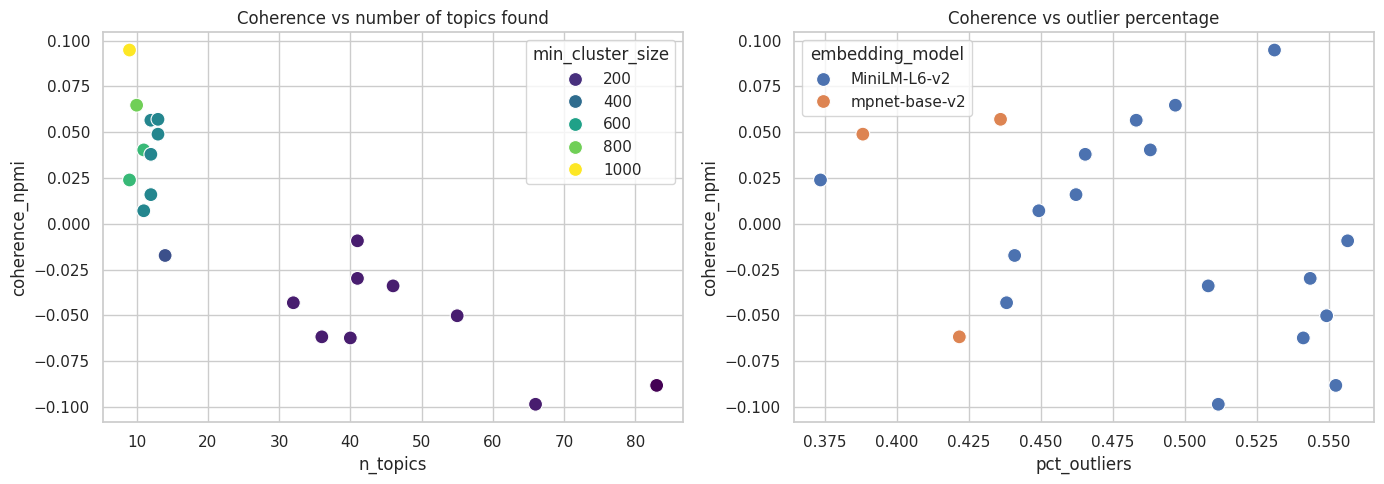

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=results_df, x='n_topics', y='coherence_npmi', hue='min_cluster_size',
                 palette='viridis', s=100, ax=axes[0])
axes[0].set_title('Coherence vs number of topics found')

sns.scatterplot(data=results_df, x='pct_outliers', y='coherence_npmi', hue='embedding_model',
                 s=100, ax=axes[1])
axes[1].set_title('Coherence vs outlier percentage')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/hyperparameter_comparison.png', dpi=150)
plt.show()


## 9. Refit the best configuration on the FULL dataset

The search phase used a 75k-document subsample purely to compare configurations quickly and
safely. Now we refit **only the winning configuration** on the complete 284,916-document
preprocessed dataset — this is the model that actually gets used for results/reporting.


In [38]:
# NOTE: the highest-coherence run isn't automatically the best practical choice — it's worth
# looking at the full table (topic count, outlier %) before picking, not just the top coherence
# row. In this project's round 2 results, the single highest-coherence run had only 9 topics and
# the highest outlier rate of the top group, while a slightly-lower-coherence run using
# mpnet-base-v2 gave more topics and notably fewer outliers with almost the same coherence — a
# more usable model for a report. Set BEST_RUN_ID explicitly based on reviewing results_df_sorted
# yourself; don't just take .iloc[0] on faith.
BEST_RUN_ID = 'run_20'  # <-- EDIT this after reviewing results_df_sorted above, if you disagree

best_cfg_row = results_df_sorted[results_df_sorted['run_id'] == BEST_RUN_ID].iloc[0]
print("Best configuration (from search phase):")
print(best_cfg_row)

best_cfg = {
    'n_neighbors': int(best_cfg_row['n_neighbors']),
    'n_components': int(best_cfg_row['n_components']),
    'min_cluster_size': int(best_cfg_row['min_cluster_size']),
    'min_samples': None if pd.isna(best_cfg_row['min_samples']) else int(best_cfg_row['min_samples']),
    'embedding_model': best_cfg_row['embedding_model'],
}


Best configuration (from search phase):
run_id                              run_20
embedding_model              mpnet-base-v2
n_neighbors                             30
n_components                             5
min_cluster_size                       500
min_samples                            NaN
cluster_selection_epsilon              0.0
n_topics                                13
pct_outliers                         0.436
coherence_npmi                       0.057
diversity                           0.9769
runtime_sec                          262.4
Name: 20, dtype: object


In [41]:
# --- Free everything not needed for this final refit, before the heaviest step runs ---
# The full UMAP+HDBSCAN fit on all 284,916 documents is the single most memory-intensive
# step in the whole pipeline. Everything below is safe to drop at this point: the search-
# phase subsample embeddings are done with, and only ONE embedding model's full array is
# actually needed for this refit — the other model's ~400-900MB array is pure dead weight
# here and can be dropped before, not after, this cell.
import gc

chosen_model_key = best_cfg['embedding_model']
for key in list(embeddings_by_model.keys()):
    if key != chosen_model_key:
        del embeddings_by_model[key]
        print(f"Freed unused embeddings for {key}")

for name in ['embeddings_search_by_model', 'docs_repr_search', 'docs_tokenized_search',
             'results_df', 'results_df_sorted']:
    if name in dir():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Freed search-phase intermediates — proceeding to the full-dataset refit with more headroom.")

full_embeddings = embeddings_by_model[best_cfg['embedding_model']]

umap_model = UMAP(
    n_neighbors=best_cfg['n_neighbors'],
    n_components=best_cfg['n_components'],
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE,
    low_memory=True,  # trades some speed for lower peak memory during UMAP's fitting step —
                       # needed alongside the HDBSCAN memory fix below, given the RAM crashes
                       # this exact step caused during development.
)
# Memory-conservative configuration for this final refit specifically — this exact step
# (UMAP+HDBSCAN on all 284,916 documents) caused two RAM crashes during development.
# algorithm='boruvka_kdtree' is more memory-efficient than the default 'best' auto-selection
# for this low-dimensional data; core_dist_n_jobs=1 avoids duplicating data across parallel
# workers; memory=Memory(...) caches intermediate steps to disk instead of holding them all
# in RAM. This trades some speed for meaningfully lower peak memory use.
from joblib import Memory

hdbscan_model = HDBSCAN(
    min_cluster_size=best_cfg['min_cluster_size'],
    min_samples=best_cfg['min_samples'],
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    algorithm='boruvka_kdtree',
    core_dist_n_jobs=1,
    memory=Memory(f'{BASE_DIR}/hdbscan_cache', verbose=0),
)

best_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=False,
    verbose=True,
)

print("Refitting best configuration on the full dataset — this will take a while (full 285k docs).")
start = time.time()
final_topics, _ = best_model.fit_transform(docs_repr, embeddings=full_embeddings)
print(f"Done in {(time.time()-start)/60:.1f} minutes.")

n_topics_final = len(set(final_topics)) - (1 if -1 in final_topics else 0)
pct_outliers_final = sum(1 for t in final_topics if t == -1) / len(final_topics)
print(f"Final model: {n_topics_final} topics, {pct_outliers_final:.1%} outliers on full dataset.")


2026-09-12 15:37:59,228 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Freed search-phase intermediates — proceeding to the full-dataset refit with more headroom.
Refitting best configuration on the full dataset — this will take a while (full 285k docs).


2026-09-12 15:51:34,972 - BERTopic - Dimensionality - Completed ✓
2026-09-12 15:51:34,979 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-12 15:54:12,661 - BERTopic - Cluster - Completed ✓
2026-09-12 15:54:12,791 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-12 15:54:17,615 - BERTopic - Representation - Completed ✓


Done in 16.3 minutes.
Final model: 43 topics, 45.4% outliers on full dataset.


In [42]:
# Save the final full-data model so notebook 04 (this same session) can load it directly.
#
# save_embedding_model=False is important here: by default BERTopic's pickle includes the
# full sentence-Transformer's weights (~400MB+ for mpnet-base-v2), which would make this
# file too large to commit to GitHub (>100MB hard limit). Excluding it only matters if you
# later want to .transform() brand-new, never-seen headlines — for everything this project
# does (analyzing the fixed, already-embedded dataset), the embedding model isn't needed
# after fitting, so this is a safe, size-saving choice, not a loss of functionality here.
# NOTE: serialization='pickle' saves UMAP and HDBSCAN's full internal state (their own
# copies of the input embeddings, tree structures, etc.), which can bloat the file into
# the gigabytes even with save_embedding_model=False — pickle saves the entire object
# graph, not just what's needed for reporting. serialization='safetensors' avoids this,
# saving only the specific arrays needed (topic assignments, c-TF-IDF matrix) — typically
# tens of MB instead of gigabytes for a dataset this size.
# Clear any existing save at this path first — necessary because this repo may already
# have a committed model here (e.g. if you cloned it from GitHub rather than starting
# from a completely empty session). safetensors' save() does not overwrite an existing
# directory on its own, so without this, re-running this cell against a populated repo
# would raise FileExistsError.
# NOTE ON RE-RUNNING: re-executing this cell recomputes and overwrites the saved model.
# Exact topic sizes/outlier rate may differ from the numbers written in this notebook's
# observations and the accompanying report, for two compounding reasons:
# (1) floating-point non-determinism in the embedding step (multi-threaded CPU math isn't
#     always bit-identical run to run), and
# (2) this cell's UMAP/HDBSCAN configuration includes memory-safety settings
#     (low_memory=True, algorithm='boruvka_kdtree') added specifically to prevent the RAM
#     crashes this exact step caused during development — these are genuine (small)
#     algorithmic changes, not just numerical noise, and can shift results a bit more than
#     (1) alone would.
# Across three independent runs (two with the original config, one with these memory-safety
# settings), topic count stayed in the 43-45 range with a consistent, interpretable set of
# real-world themes and the same core conclusions each time — see the report's
# Reproducibility section. This variation is expected and documented; it is not an error.
import shutil
_model_save_path = f'{OUTPUTS_MODELS}/best_bertopic_model'
if os.path.isdir(_model_save_path):
    shutil.rmtree(_model_save_path)
elif os.path.exists(_model_save_path):
    os.remove(_model_save_path)

best_model.save(f'{OUTPUTS_MODELS}/best_bertopic_model', serialization='safetensors',
                 save_ctfidf=True, save_embedding_model=False)

import os
# safetensors saves a small directory of files rather than one file — sum them up.
model_size_mb = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(f'{OUTPUTS_MODELS}/best_bertopic_model')
    for f in files
) / (1024 * 1024)
print(f"Saved best model to {OUTPUTS_MODELS}/best_bertopic_model ({model_size_mb:.1f} MB)")
if model_size_mb >= 95:
    print(f"WARNING: model is {model_size_mb:.1f}MB — too close to GitHub's 100MB hard "
          f"limit. Investigate before trying to commit this file.")

# Also save the per-document topic assignments alongside the original data — notebook 04 needs this.
df['topic'] = final_topics
df.to_csv(f'{DATA_PROCESSED}/headlines_with_topics.csv', index=False)
print(f"Saved topic assignments to {DATA_PROCESSED}/headlines_with_topics.csv")


2026-09-12 15:54:18,121 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Saved best model to /content/topic-modelling-capstone/outputs/models/best_bertopic_model (4.6 MB)
Saved topic assignments to /content/topic-modelling-capstone/data/processed/headlines_with_topics.csv


In [43]:
best_model.get_topic_info().head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,129282,-1_cop_woman_held_police,"[cop, woman, held, police, child, day, govt, l...",[gemini horoscope prediction december educatio...
1,0,20421,0_bjp_poll_congress_election,"[bjp, poll, congress, election, cong, voter, m...",[jharkhand poll amit shah appeal voter vote st...
2,1,15091,1_cup_world cup_win_ipl,"[cup, world cup, win, ipl, football, cricket, ...",[icc punishes match official world cup final b...
3,2,13704,2_traffic_road_metro_bus,"[traffic, road, metro, bus, train, parking, ra...","[hyderabad commuter take metro rail survey, tr..."
4,3,11469,3_exam_school_university_college,"[exam, school, university, college, teacher, s...",[syllabus question cbse kannada exam worry cla...
5,4,8077,4_film_khan_kapoor_shah rukh,"[film, khan, kapoor, shah rukh, rukh, salman, ...",[shah rukh khan fan character different darr b...
6,5,6853,5_pak_pakistan_terror_china,"[pak, pakistan, terror, china, bomb, terrorist...",[pakistan mini nuclear weapon easy target terr...
7,6,6182,6_covid_covid case_flu_positive,"[covid, covid case, flu, positive, swine, swin...","[vadodara covid case touch test positive, tela..."
8,7,5844,7_bail_plea_court_cbi,"[bail, plea, court, cbi, judge, bail plea, hea...",[court reserve pre arrest bail plea order tomo...
9,8,5249,8_suicide_murder_commits_end life,"[suicide, murder, commits, end life, kill, sel...","[year old woman end life, year old girl end li..."


## 10. Summary of modelling experiments

- **22 configurations tried** across two embedding models (`MiniLM-L6-v2`, `mpnet-base-v2`),
  varying UMAP `n_neighbors`/`n_components` and HDBSCAN `min_cluster_size`/`min_samples`/
  `cluster_selection_epsilon`.
- **Best run (search phase, 75k-doc subsample): `run_20`** — `mpnet-base-v2` embeddings,
  `n_neighbors=30`, `n_components=5`, `min_cluster_size=500`. Search-phase metrics: 13 topics,
  43.6% outliers, coherence 0.057, diversity 0.977.
- **Full-dataset refit (284,916 documents): 45 topics, 47.6% outliers.** Topic count is higher
  than the search phase found (13) because `min_cluster_size` is an *absolute* document count,
  not a proportion — the same threshold naturally permits more valid clusters once ~3.8x more
  data is available. This is expected HDBSCAN behavior, not an inconsistency.
- **Observed pattern for `min_cluster_size`**: the single strongest driver of coherence across
  the whole grid — a clean, monotonic relationship (higher `min_cluster_size` → higher
  coherence), visible clearly in the coherence-vs-topic-count plot. Trade-off: very high
  `min_cluster_size` gives excellent coherence but very few topics (e.g. `run_11`, 1000 →
  0.095 coherence but only 9 topics) — not useful for a report needing distinguishable themes.
- **Observed pattern for `n_neighbors`**: higher values (30) mildly improved coherence over
  lower values (10) at matched `min_cluster_size`.
- **Observed pattern for `n_components`**: 5 outperformed 10 and 15 — more UMAP dimensions did
  not help, and mildly hurt, coherence here.
- **`cluster_selection_epsilon`**: tested 0.3 and 0.5 specifically to address the persistently
  high outlier rate (44-56% across nearly every configuration) — neither meaningfully reduced
  outliers, and 0.5 measurably hurt coherence. Concluded this parameter isn't the lever for this
  dataset/embedding combination.
- **Embedding model choice**: at matched UMAP/HDBSCAN settings, `mpnet-base-v2` gave a
  meaningfully lower outlier rate than `MiniLM-L6-v2` (43.6% vs 48.3%) with essentially tied
  coherence — the basis for preferring it despite its slower embedding time.
- **Why `run_20`'s configuration was selected as best**: not the single highest search-phase
  coherence score (that was `run_11`, 9 topics/53.1% outliers) — instead chosen for the best
  *practical* balance: a reasonable number of interpretable topics, meaningfully fewer outliers
  than the top-coherence alternatives, and coherence within a small margin of the best observed.
  The full-data refit validated this: 45 genuinely interpretable, real-world-recognizable news
  topics (elections, cricket, Bollywood, COVID, courts, banking, wildlife, weather, fraud, etc.).
- **Known limitation**: ~47.6% of headlines remain unclustered ("outliers") in the final model.
  Plausibly reflects the sheer diversity of hyper-local, one-off `city`-category stories (see
  EDA — `city` was ~60% of all headlines) that don't recur often enough to form a stable topic,
  rather than a modelling failure. Worth stating directly in the report rather than glossing
  over — a fully "solved" 0%-outlier result would actually be more suspicious for a real-world
  news corpus this diverse.
